# ***<center>Clasificare folosind DenseNet201<center>***

In acest notebook construim un model de clasificare pe datasetul **FGVC Aircraft** utilizand **DenseNet201** preantrenat pe ImageNet. DenseNet este o arhitectura CNN moderna bazata pe conexiuni dense intre layere.

## <center>1: Librarii si enviroment<center>
Se initializeaza parametrii globali si se configureaza `AUTOTUNE` pentru optimizarea pipeline-ului de date.  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re

pd.set_option('display.max_colwidth', 200)

In [3]:
import tarfile
import scipy.io
from collections import defaultdict

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import *
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import backend as K
from tensorflow.keras import activations as Ac

AUTO = tf.data.experimental.AUTOTUNE

## <center>2: Dataset si verificare<center>
Datasetul **FGVC Aircraft** este impartit in `train`, `val` si `test`.  
Se citesc fisierele CSV corespunzatoare, se afiseaza dimensiunile seturilor si cateva exemple pentru verificare.  


In [8]:
train = pd.read_csv('../input/fgvc-aircraft/train.csv')
val = pd.read_csv('../input/fgvc-aircraft/val.csv')
test = pd.read_csv('../input/fgvc-aircraft/test.csv')

In [9]:
print(train.shape)
train.head()

(3334, 3)


,filename,Classes,Labels
0,1025794.jpg,707-320,0
1,1340192.jpg,707-320,0
2,0056978.jpg,707-320,0
3,0698580.jpg,707-320,0
4,0450014.jpg,707-320,0


In [10]:
tpath = "../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images"

In [11]:
train_paths = train.filename.apply(lambda x: os.path.join(tpath, x))
print(train_paths.values)

val_paths = val.filename.apply(lambda x: os.path.join(tpath, x))
print(val_paths.values)

test_paths = test.filename.apply(lambda x: os.path.join(tpath, x))
print(test_paths.values)

['../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/1025794.jpg'
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/1340192.jpg'
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/0056978.jpg'
 ...
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/0472681.jpg'
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/1597829.jpg'
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/0197891.jpg']
['../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/0481847.jpg'
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/0810608.jpg'
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/1514481.jpg'
 ...
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/1340345.jpg'
 '../input/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/0765754.jpg'

## <center>3: One hot encoding<center>
Etichetele claselor sunt transformate in vectori one-hot folosind `to_categorical`.  
Aceasta reprezentare este standard pentru problemele de clasificare multi-clasa si permite folosirea functiei `categorical_crossentropy`.  


In [12]:
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train.Labels)
print(train_labels.shape)

val_labels = to_categorical(val.Labels)
print(val_labels.shape)

(3334, 100)
(3333, 100)


## <center>4: Procesare si augmentare pe imagini<center>
Definim functia `decode_image` care citeste imaginea JPEG, o normalizaza in [0,1], o redimensioneaza la 299x299 si o returneaza impreuna cu eticheta.  

Definim functia `augment` care aplica transformari de data augmentation:  
- flip orizontal si vertical,  
- variatii de luminozitate, contrast, saturatie si hue,  
- rotatii aleatorii la 90 de grade.  

In [13]:
def decode_image(filename, label=None, image_size=(299, 299)):
    bits = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(bits, channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, image_size)
    
    if label is None:
        return image
    else:
        return image, label

In [14]:
# def augment(image, label=None):
#     image = tf.image.random_flip_left_right(image)
    
#     if label is None:
#         return image
#     else:
#         return image, label

# def augment(image, label):
#     image = tf.image.random_flip_left_right(image)
#     image = tf.image.random_flip_up_down(image)
#     image = tf.image.random_brightness(image, max_delta=0.2)
#     image = tf.image.random_contrast(image, 0.8, 1.2)
#     image = tf.image.random_saturation(image, 0.8, 1.2)
#     image = tf.image.random_hue(image, 0.1)
#     return image, label

def augment(image, label):
    # Flip aleator pe orizontala si verticala
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    # Brightness si contrast
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, 0.7, 1.3)
    # Saturation si hue
    image = tf.image.random_saturation(image, 0.7, 1.3)
    image = tf.image.random_hue(image, 0.1)
    # Optional: rotatie aleatorie
    image = tf.image.rot90(image, k=np.random.randint(4))
    return image, label


## <center>5: Dataset-urile de tip TF<center>

Imaginile sunt incarcate intr-un `tf.data.Dataset`, unde:  
- sunt decode-uite si augmentate,  
- grupate in batch-uri,  
- preprocesate in paralel folosind `AUTOTUNE`.  

Se creeaza pipeline-uri separate pentru train, validare si test, optimizate pentru performanta pe GPU.  


In [15]:
batch_size = 16

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((train_paths, train_labels))
    .map(decode_image, num_parallel_calls=AUTO)
    .map(augment, num_parallel_calls=AUTO)
    .repeat()
    .shuffle(2048)
    .batch(batch_size)
    .prefetch(AUTO)
)

val_dataset = (tf.data.Dataset
        .from_tensor_slices((val_paths, val_labels))
        .map(decode_image, num_parallel_calls=AUTO)
        .batch(batch_size)
)

test_dataset = (tf.data.Dataset
        .from_tensor_slices(test_paths)
        .map(decode_image, num_parallel_calls=AUTO)
        .batch(batch_size)
)

## <center>6: Callback pentru LR<center>

`CyclicLR` este un scheduler pentru learning rate care oscileaza intre doua valori presetate.  

Scopul lui este:  
- sa ajute optimizer-ul sa iasa din minime locale,  
- sa exploreze mai bine spatiul de parametri,  
- sa accelereze convergenta in anumite cazuri.  


In [16]:
class CyclicLR(tf.keras.callbacks.Callback):
    def __init__(self, base_lr=0.001, max_lr=0.006, step_size=2000., mode='triangular', gamma=1., scale_fn=None, scale_mode='cycle'):
        super(CyclicLR, self).__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size
        self.mode = mode
        self.gamma = gamma
        if scale_fn is None:
            if self.mode == 'triangular':
                self.scale_fn = lambda x: 1.
                self.scale_mode = 'cycle'
            elif self.mode == 'triangular2':
                self.scale_fn = lambda x: 1/(2.**(x-1))
                self.scale_mode = 'cycle'
            elif self.mode == 'exp_range':
                self.scale_fn = lambda x: gamma**(x)
                self.scale_mode = 'iterations'
        else:
            self.scale_fn = scale_fn
            self.scale_mode = scale_mode
        self.clr_iterations = 0.
        self.trn_iterations = 0.
        self.history = {}
        self._reset()

    def _reset(self, new_base_lr=None, new_max_lr=None, new_step_size=None):
        if new_base_lr is not None:
            self.base_lr = new_base_lr
        if new_max_lr is not None:
            self.max_lr = new_max_lr
        if new_step_size is not None:
            self.step_size = new_step_size
        self.clr_iterations = 0.

    def clr(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        if self.scale_mode == 'cycle':
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(cycle)
        else:
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(self.clr_iterations)

    def on_train_begin(self, logs=None):
        logs = logs or {}
        if self.clr_iterations == 0:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.base_lr)
        else:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.clr())

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.trn_iterations += 1
        self.clr_iterations += 1

        self.history.setdefault('lr', []).append(tf.keras.backend.get_value(self.model.optimizer.lr))
        self.history.setdefault('iterations', []).append(self.trn_iterations)

        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)

        tf.keras.backend.set_value(self.model.optimizer.lr, self.clr())


## <center>7: Construirea modelului bazat pe DenseNet<center>
Se adauga:  
- `GlobalAveragePooling2D` pentru a reduce dimensiunea spatiala,  
- `BatchNormalization` pentru stabilizarea antrenarii,  
- `Dropout` pentru regularizare,  
- strat `Dense` final cu numar de neuroni egal cu clasele datasetului.  

Modelul este compilat cu:  
- `Adam` optimizer,  
- learning rate adaptiv,  
- loss `categorical_crossentropy`,  
- metrici `accuracy`.  


In [39]:
def mish(x):
    return x * K.tanh(Ac.softplus(x))


from tensorflow.keras import regularizers

model = tf.keras.Sequential([
        DenseNet201(weights = 'imagenet', 
                       include_top = False,
                       input_shape = (299, 299, 3)),
    
        GlobalAveragePooling2D(),
        # Dense(1024, activation = mish),
        Dense(1024, activation=mish, kernel_regularizer=regularizers.l2(0.002)),
        BatchNormalization(),
        Dropout(0.7),
        Dense(512, activation=mish, kernel_regularizer=regularizers.l2(0.002)),
        BatchNormalization(),
        Dropout(0.6),
        Dense(100, activation = 'softmax')
])
    
optimizer = SGD()
# optimizer = Adam()
model.compile(optimizer = optimizer,
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
    
model.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
densenet201 (Model)          (None, 9, 9, 1920)        18321984  
_________________________________________________________________
global_average_pooling2d_9 ( (None, 1920)              0         
_________________________________________________________________
dense_27 (Dense)             (None, 1024)              1967104   
_________________________________________________________________
batch_normalization_18 (Batc (None, 1024)              4096      
_________________________________________________________________
dropout_18 (Dropout)         (None, 1024)              0         
_________________________________________________________________
dense_28 (Dense)             (None, 512)               524800    
_________________________________________________________________
batch_normalization_19 (Batc (None, 512)              

## <center>8: Antrenarea modelului<center>
Se folosesc callback-uri:  
- `ModelCheckpoint` pentru salvarea celui mai bun model,  
- `EarlyStopping` pentru oprirea antrenarii cand nu mai exista imbunatatiri,  
- `ReduceLROnPlateau` pentru ajustarea learning rate-ului automat.  

In [36]:
def Train_model(model, batch_size, EPOCHS):
    n_steps = train_labels.shape[0] // batch_size
    EPOCHS = EPOCHS
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss', 
                                                     factor = 0.5,
                                                     patience = 3, 
                                                     min_lr = 1e-5,
                                                     verbose = 1)
    

    clr = CyclicLR(base_lr = 0.001, max_lr = 0.01, step_size = 2000, mode = 'triangular',)

    # Early stopping pentru a preveni overfitting-ul
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    Model = model
    history = Model.fit(train_dataset, 
                    steps_per_epoch = n_steps,
                    epochs = EPOCHS,
                    validation_data = val_dataset,
                    callbacks = [clr, reduce_lr, early_stop],
                    verbose = 1)
    
    return Model

In [40]:
batch_size = 16
EPOCHS = 40

def check(x, y):
    if x == y:
        return 1
    else:
        return 0

print('Training')
model = Train_model(model, batch_size, EPOCHS)
model.save('aircraft_model.h5')

Training
Epoch 1/40
208/208 [==============================] - 77s 371ms/step - loss: 10.4798 - accuracy: 0.0123 - val_loss: 8.8237 - val_accuracy: 0.0102 - lr: 0.0019
Epoch 2/40
208/208 [==============================] - 74s 357ms/step - loss: 10.3063 - accuracy: 0.0129 - val_loss: 10.5578 - val_accuracy: 0.0168 - lr: 0.0029
Epoch 3/40
208/208 [==============================] - 74s 357ms/step - loss: 9.9483 - accuracy: 0.0159 - val_loss: 8.4033 - val_accuracy: 0.0645 - lr: 0.0038
Epoch 4/40
208/208 [==============================] - 74s 355ms/step - loss: 9.5351 - accuracy: 0.0312 - val_loss: 8.0959 - val_accuracy: 0.0696 - lr: 0.0047
Epoch 5/40
208/208 [==============================] - 74s 357ms/step - loss: 9.0877 - accuracy: 0.0484 - val_loss: 7.9065 - val_accuracy: 0.0897 - lr: 0.0057
Epoch 6/40
208/208 [==============================] - 75s 361ms/step - loss: 8.6018 - accuracy: 0.0727 - val_loss: 7.6112 - val_accuracy: 0.1233 - lr: 0.0066
Epoch 7/40
208/208 [====================

## <center>9: Continuarea/Reluarea antrenarii<center>
Aceasta este utila cand:  
- se doreste continuarea antrenarii cu alti hiperparametri,  
- se vrea prelungirea numarului de epoci,  
- se experimenteaza cu noi callback-uri sau augmentari.  

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/kaggle/working/aircraft_model.h5')
EXTRA_EPOCHS = 10 

model = Train_model(model, batch_size, EXTRA_EPOCHS)

model.save('/kaggle/working/aircraft_model.h5')


## <center>10: Predictii si evaluarea modelului<center>
Se calculeaza accuracy final si se afiseaza predictiile comparativ cu etichetele reale.  

In [41]:
pred = model.predict(test_dataset, verbose=1)

test['Prediction'] = pred.argmax(axis=1)
test['Score'] = test.apply(lambda x: check(x['Prediction'], x['Labels']), axis=1)
print('Test accuracy on iterations is ', 100 * test.Score.sum() / test.shape[0])

209/209 [==============================] - 18s 87ms/step
Test accuracy on iterations is  77.7977797779778


In [42]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test.Labels, test.Prediction))

              precision    recall  f1-score   support

           0       0.64      0.76      0.69        33
           1       0.78      0.94      0.85        33
           2       0.93      0.79      0.86        34
           3       0.64      0.42      0.51        33
           4       0.52      0.76      0.62        33
           5       0.67      0.71      0.69        34
           6       0.67      0.73      0.70        33
           7       0.67      0.61      0.63        33
           8       0.83      0.44      0.58        34
           9       0.81      0.88      0.84        33
          10       0.42      0.45      0.43        33
          11       0.30      0.24      0.26        34
          12       0.39      0.39      0.39        33
          13       0.50      0.45      0.48        33
          14       0.87      0.76      0.81        34
          15       1.00      0.85      0.92        33
          16       0.78      0.55      0.64        33
          17       0.48    

## <center>11: Vizualizarea rezultatelor<center>  
Se afiseaza cateva exemple de imagini cu predictiile DenseNet201 versus eticheta corecta. 

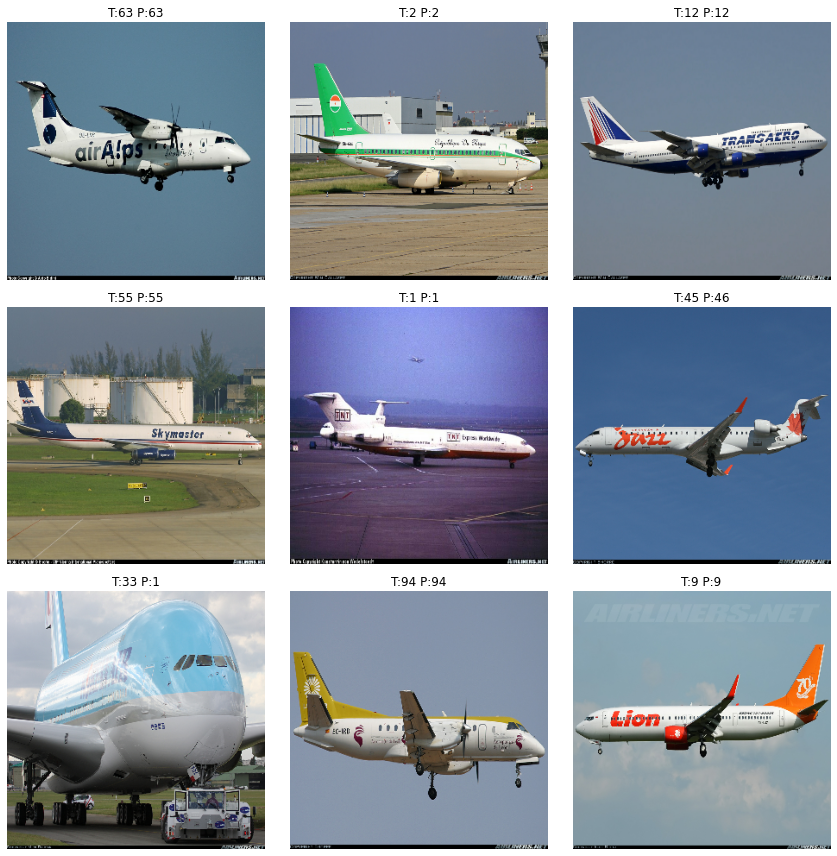

In [43]:
import matplotlib.pyplot as plt
import random

# luam test_paths si test.Labels din dataframe-ul test
n_samples = 9
indices = random.sample(range(len(test)), n_samples)

plt.figure(figsize=(12, 12))

for idx, i in enumerate(indices):
    # citim imaginea direct din fisier (nu din dataset)
    img = decode_image(test_paths[i]).numpy()
    
    true_class = test.loc[i, "Labels"]
    pred_class = test.loc[i, "Prediction"]

    plt.subplot(3, 3, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"T:{true_class} P:{pred_class}")

plt.tight_layout()
plt.show()
